# 02 — State Management & Clone

**Invariant proved:** State Management  
**Module built:** `clone_state()` in `sdk/core/scenario.py`

For branched counterfactual simulation, the engine must create a deep copy of state at the point of divergence. Mutations on one branch must not leak to the other. The SDK provides a default `clone_state()` using `copy.deepcopy()` with an override pattern for optimized copying.

In [1]:
import sys
sys.path.insert(0, '..')

import copy
import time
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

## 1. Mutation Isolation on Different State Types

The SDK supports generic state — numpy arrays, dataclasses, nested dicts, or any combination. `clone_state` must produce mutation-isolated copies for all of them.

In [2]:
clone = copy.deepcopy  # the default clone_state implementation

# --- Numpy array ---
original_array = np.array([0.1, 0.2, 0.3])
cloned_array = clone(original_array)
cloned_array[0] = 999.0
print(f"numpy array:  original[0]={original_array[0]} (should be 0.1)")
assert original_array[0] == 0.1

# --- Dataclass ---
@dataclass
class PatientState:
    risks: np.ndarray
    on_medication: np.ndarray

original_dc = PatientState(risks=np.array([0.05, 0.15]), on_medication=np.array([False, True]))
cloned_dc = clone(original_dc)
cloned_dc.risks[0] = 999.0
print(f"dataclass:    original.risks[0]={original_dc.risks[0]} (should be 0.05)")
assert original_dc.risks[0] == 0.05

# --- Nested dict ---
original_dict = {
    "patients": {"risks": np.array([0.1, 0.2]), "names": ["a", "b"]},
    "schedule": np.array([[1, 2], [3, 4]]),
}
cloned_dict = clone(original_dict)
cloned_dict["patients"]["risks"][0] = 999.0
cloned_dict["schedule"][0, 0] = 999
print(f"nested dict:  original risks[0]={original_dict['patients']['risks'][0]} (should be 0.1)")
print(f"nested dict:  original schedule[0,0]={original_dict['schedule'][0,0]} (should be 1)")
assert original_dict["patients"]["risks"][0] == 0.1
assert original_dict["schedule"][0, 0] == 1

print("\nMutation isolation verified for all state types.")

numpy array:  original[0]=0.1 (should be 0.1)
dataclass:    original.risks[0]=0.05 (should be 0.05)
nested dict:  original risks[0]=0.1 (should be 0.1)
nested dict:  original schedule[0,0]=1 (should be 1)

Mutation isolation verified for all state types.


## 2. Memory and Timing: `deepcopy` vs `np.copy`

For array-backed state (like the stroke scenario), `np.copy` is much faster than `deepcopy`. Scenarios can override `clone_state()` to use it.

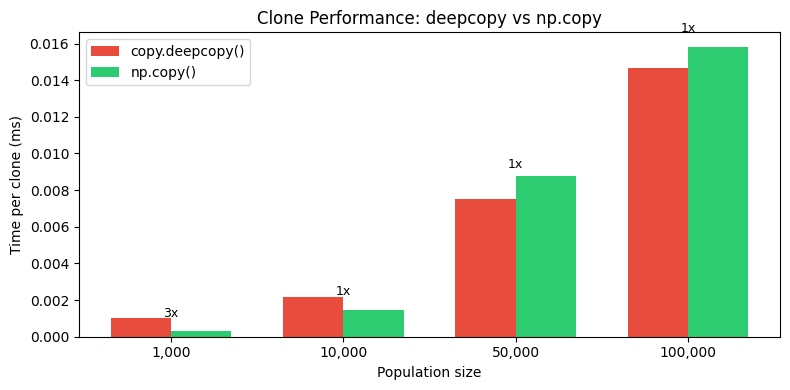


At 100k entities: deepcopy=0.01ms, np.copy=0.02ms
Guidance: start with default deepcopy. Override if profiling shows it's a bottleneck.


In [3]:
sizes = [1_000, 10_000, 50_000, 100_000]
deepcopy_times = []
npcopy_times = []
n_trials = 50

for n in sizes:
    state = np.random.random(n)

    t0 = time.perf_counter()
    for _ in range(n_trials):
        copy.deepcopy(state)
    deepcopy_times.append((time.perf_counter() - t0) / n_trials * 1000)

    t0 = time.perf_counter()
    for _ in range(n_trials):
        state.copy()
    npcopy_times.append((time.perf_counter() - t0) / n_trials * 1000)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(sizes))
width = 0.35
ax.bar([i - width/2 for i in x], deepcopy_times, width, label='copy.deepcopy()', color='#e74c3c')
ax.bar([i + width/2 for i in x], npcopy_times, width, label='np.copy()', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels([f'{s:,}' for s in sizes])
ax.set_xlabel('Population size')
ax.set_ylabel('Time per clone (ms)')
ax.set_title('Clone Performance: deepcopy vs np.copy')
ax.legend()

for i, (dc, nc) in enumerate(zip(deepcopy_times, npcopy_times)):
    speedup = dc / nc if nc > 0 else float('inf')
    ax.text(i, max(dc, nc) * 1.05, f'{speedup:.0f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nAt 100k entities: deepcopy={deepcopy_times[-1]:.2f}ms, np.copy={npcopy_times[-1]:.2f}ms")
print("Guidance: start with default deepcopy. Override if profiling shows it's a bottleneck.")

## Key Insights

1. `copy.deepcopy()` provides correct mutation isolation for any state type — the safe default.
2. For array-backed state, `np.copy()` is significantly faster and can be used via `clone_state()` override.
3. The override pattern lets scenario teams optimize without changing SDK internals.

**Next:** [03_discrete_time_engine.ipynb](03_discrete_time_engine.ipynb) — the simulation engine.